Importing the Dependencies

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_curve, auc
)
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
import warnings

In [27]:
# Configure presentation styles
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

Data Loading and Inspection

In [28]:
df = pd.read_csv('bank-additional-full.csv', sep=';', engine='python', )
display(df.head())

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [29]:
print(df.shape)

(41188, 21)


41188 observations with 21 variables

In [30]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [31]:
#checking missing values
print(df.isnull().sum())

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64


In [32]:
#check for duplicates
print(df.duplicated().sum())

12


In [33]:
# Drop duplicate rows
df.drop_duplicates(inplace=True)

In [34]:
print(df.shape)

(41176, 21)


In [35]:
print(df['y'].value_counts())

y
no     36537
yes     4639
Name: count, dtype: int64


EDA

Target Variable Distribution

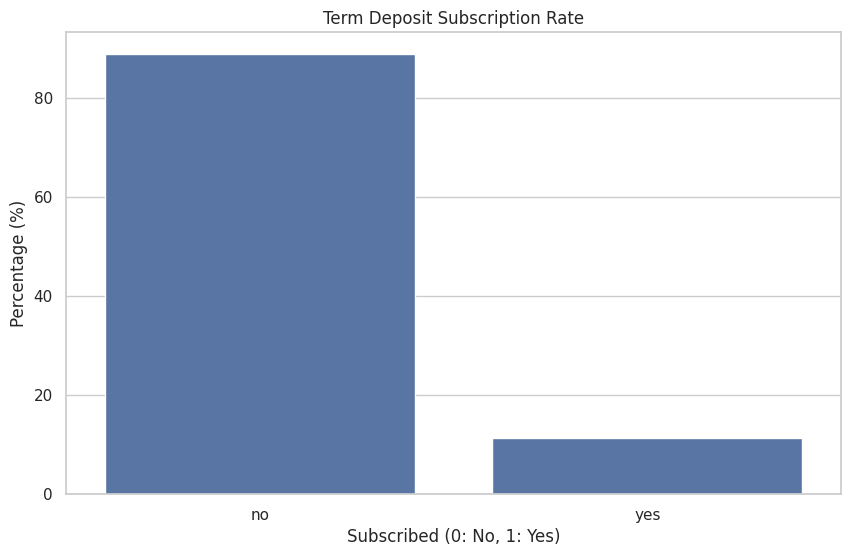

In [36]:
y_counts = df['y'].value_counts(normalize=True) * 100
sns.barplot(x=y_counts.index, y=y_counts.values, edgecolor=None, errorbar=None)
plt.title("Term Deposit Subscription Rate")
plt.xlabel("Subscribed (0: No, 1: Yes)")
plt.ylabel("Percentage (%)")
plt.show()

Distribution of Numeric Features

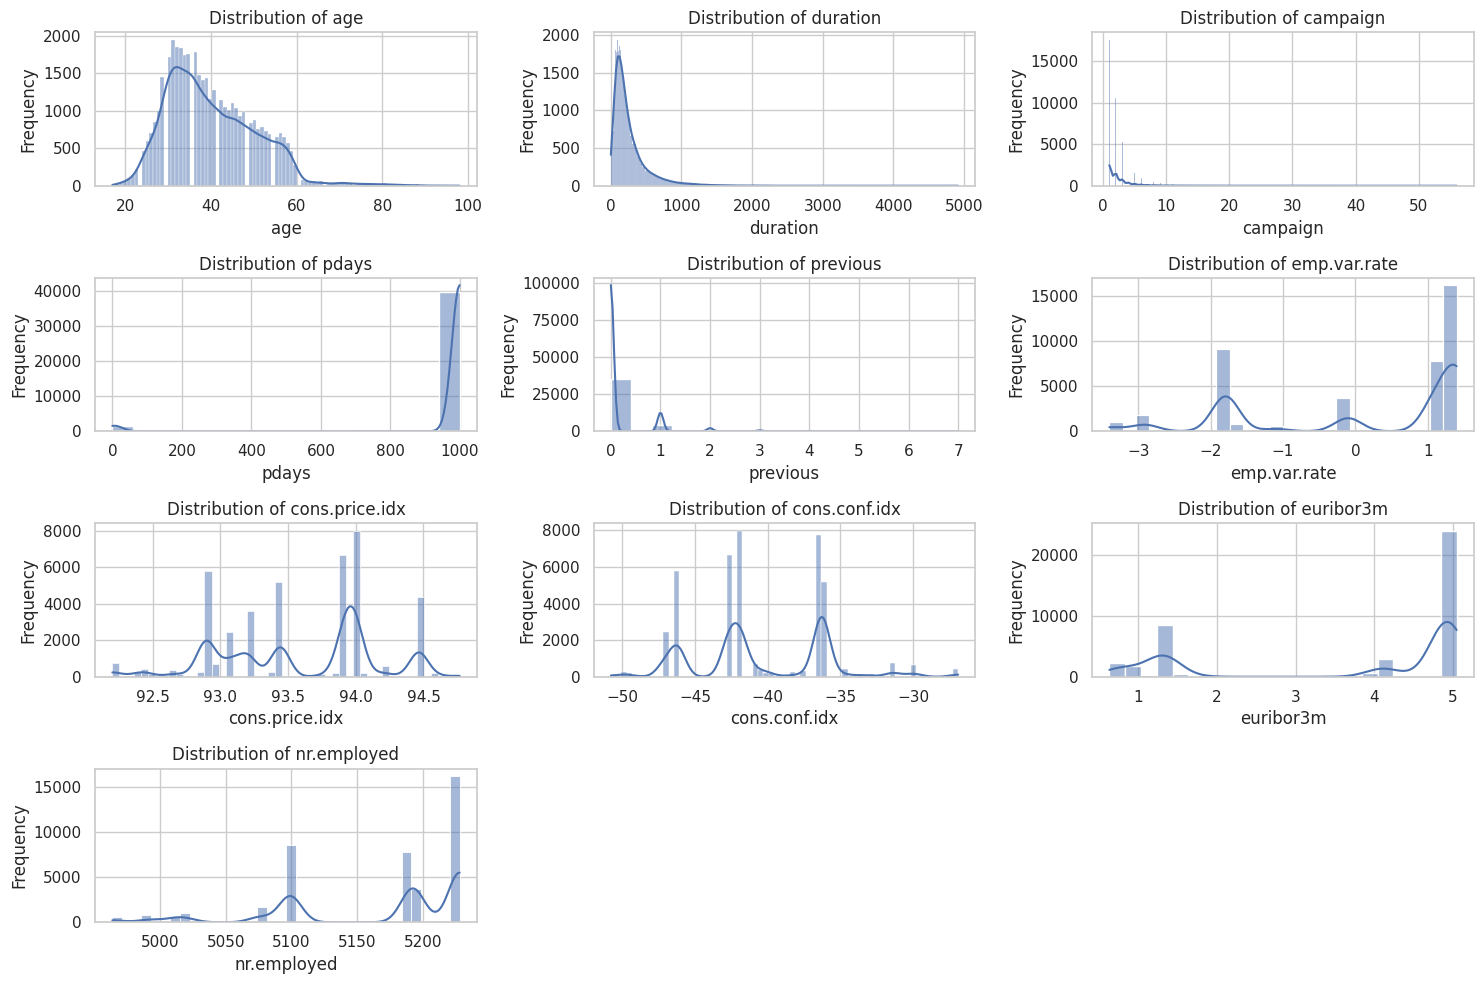

In [37]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric_cols):
    plt.subplot(4, 3, i + 1)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

Distribution of Categorical Features

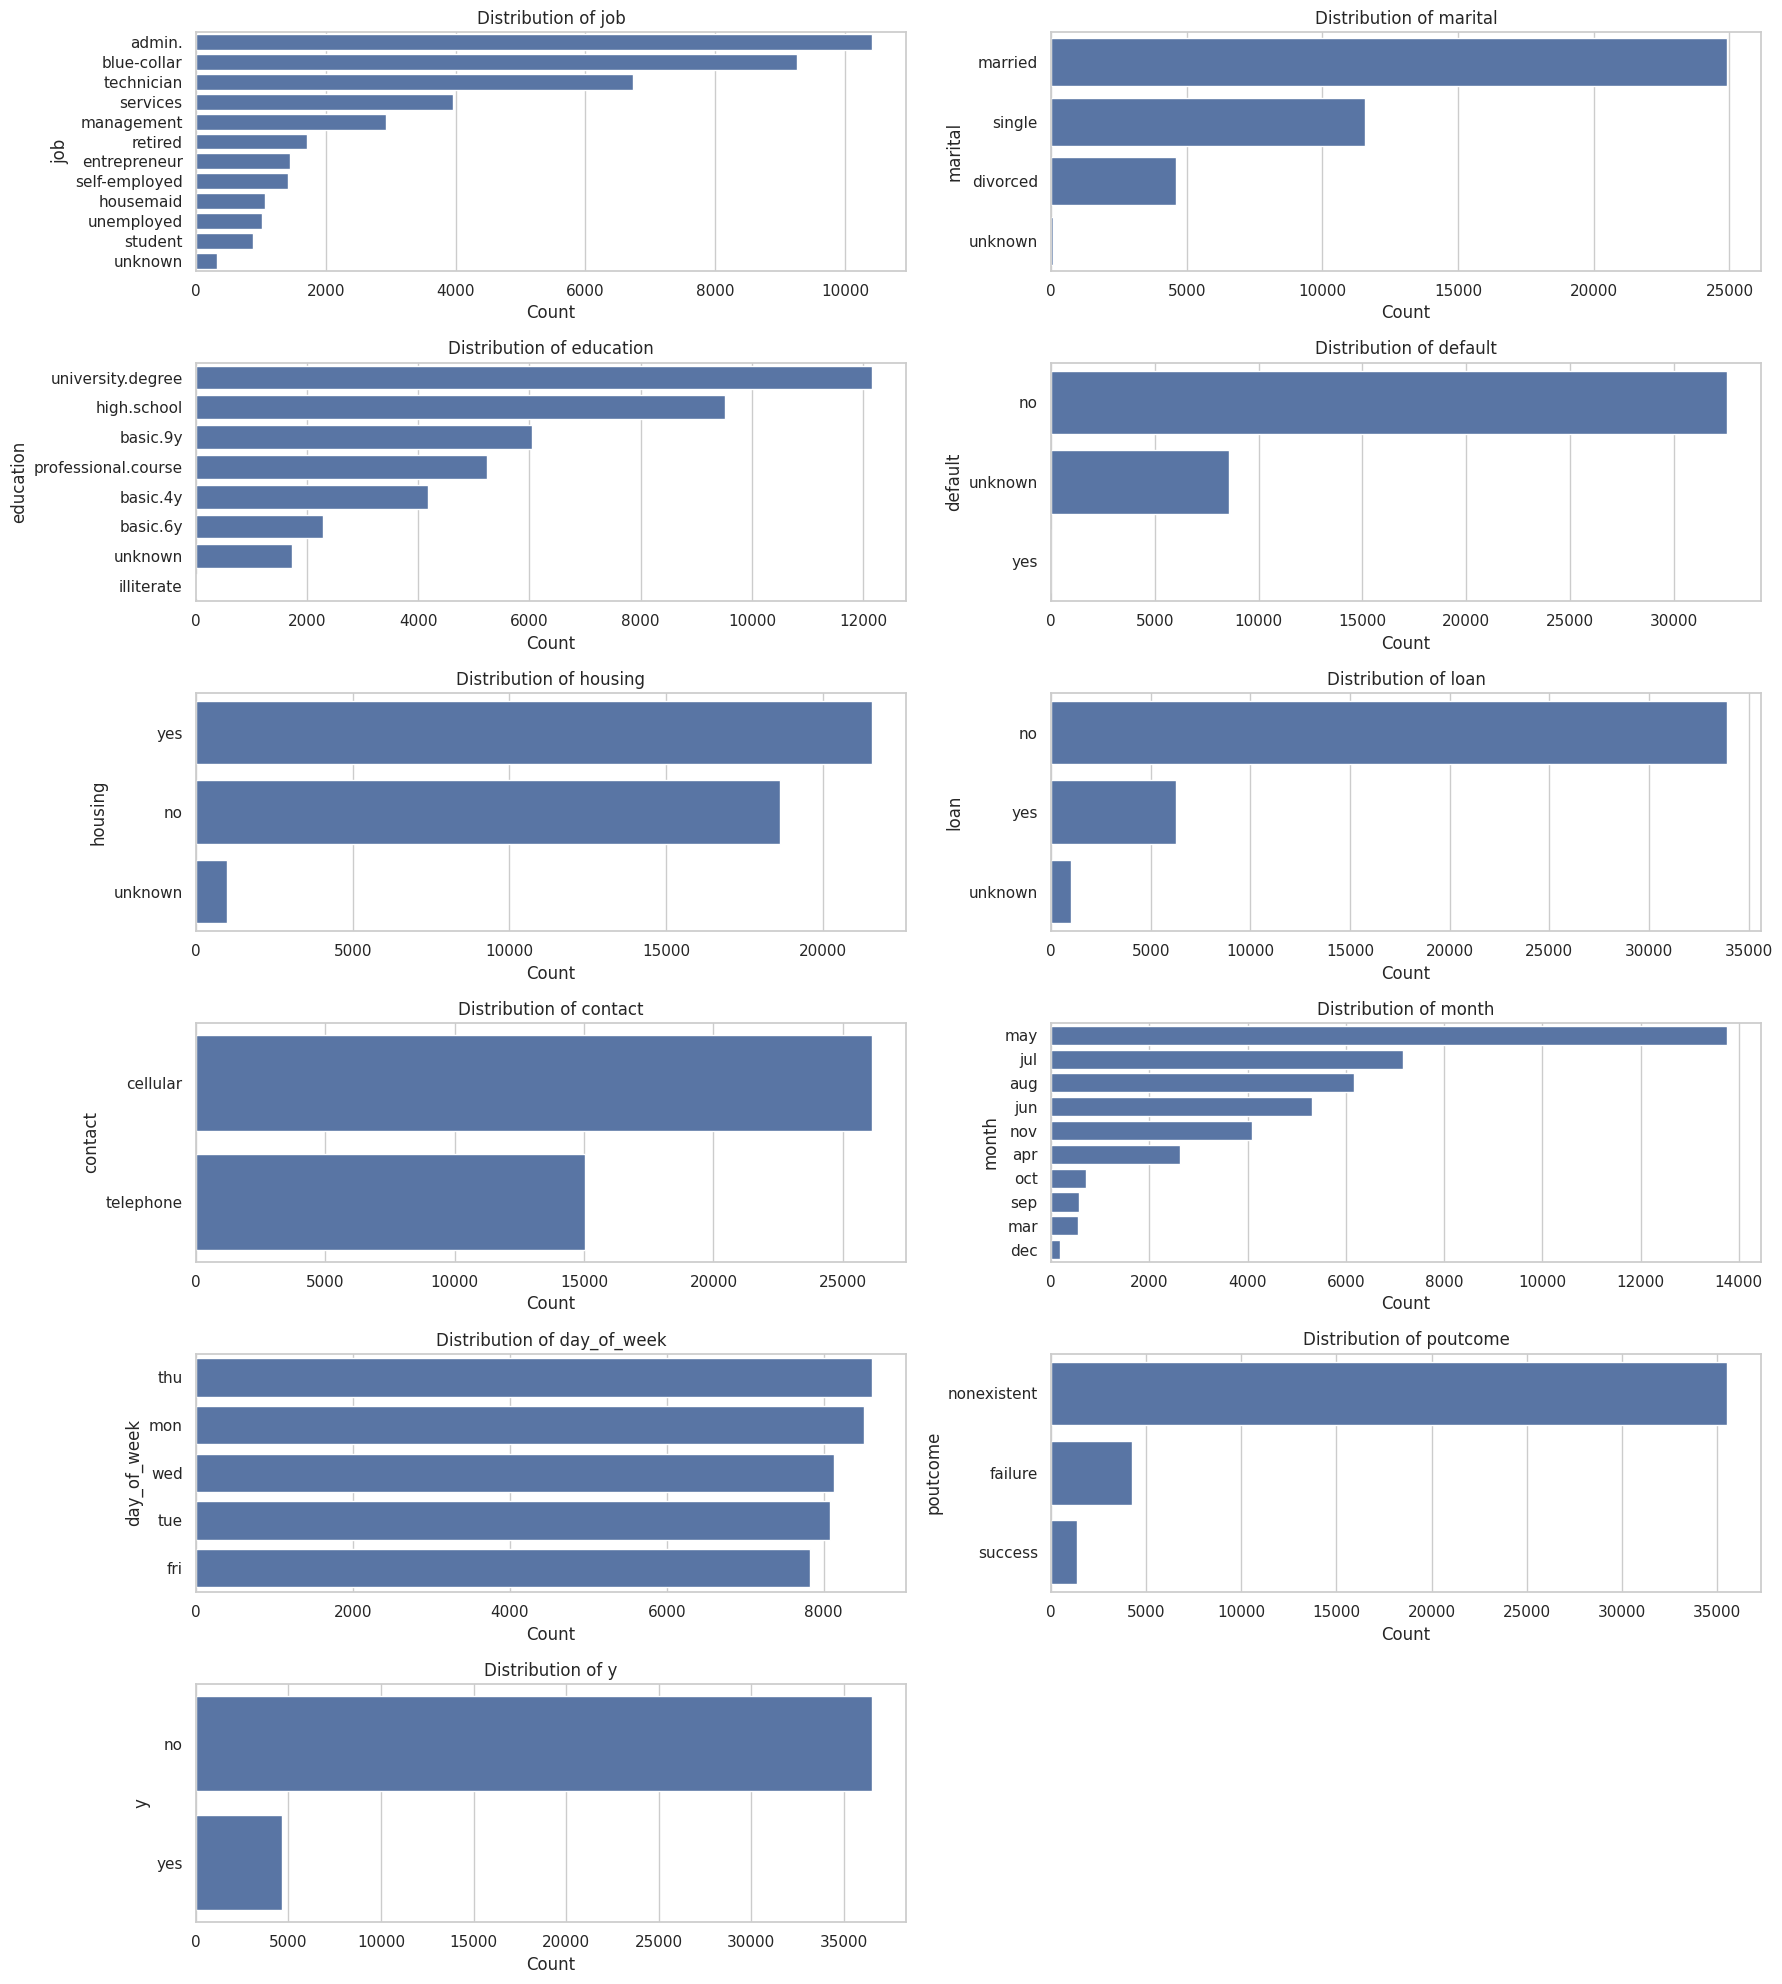

In [38]:
categorical_cols = df.select_dtypes(include='object').columns.tolist()

plt.figure(figsize=(18, 20))
for i, col in enumerate(categorical_cols):
    plt.subplot(6, 2, i + 1)
    sns.countplot(data=df, y=col, order=df[col].value_counts().index)
    plt.title(f'Distribution of {col}')
    plt.xlabel('Count')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

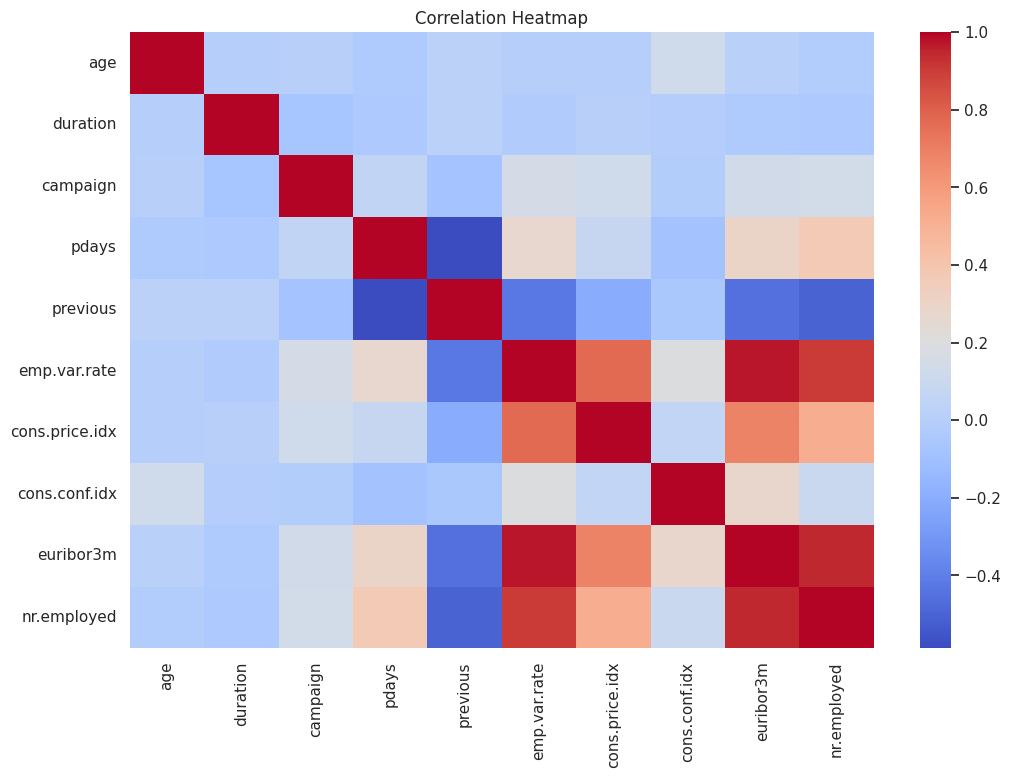

In [39]:
# Correlation heatmap
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
plt.figure(figsize=(12,8))
sns.heatmap(df[numeric_cols].corr(), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

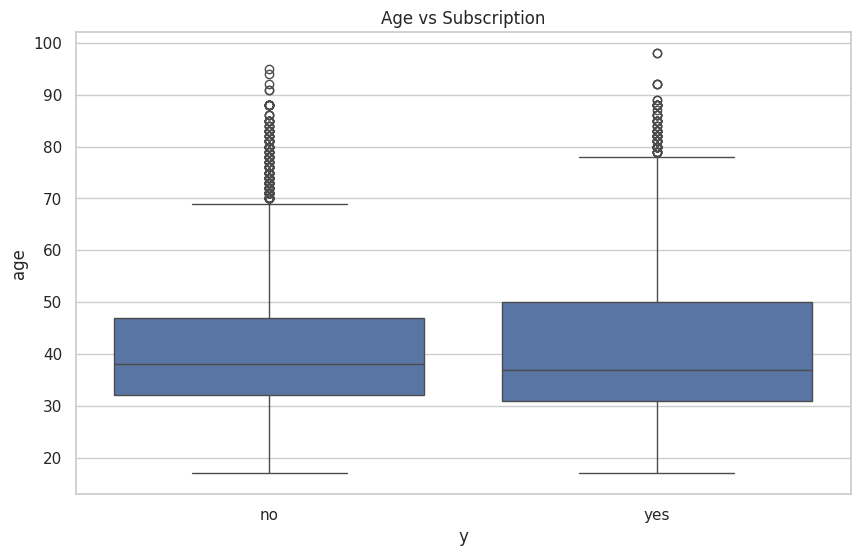

In [40]:
# Age distribution by target
sns.boxplot(x='y', y='age', data=df)
plt.title("Age vs Subscription")
plt.show()

Detailed Breakdown of Subscriptions by Job

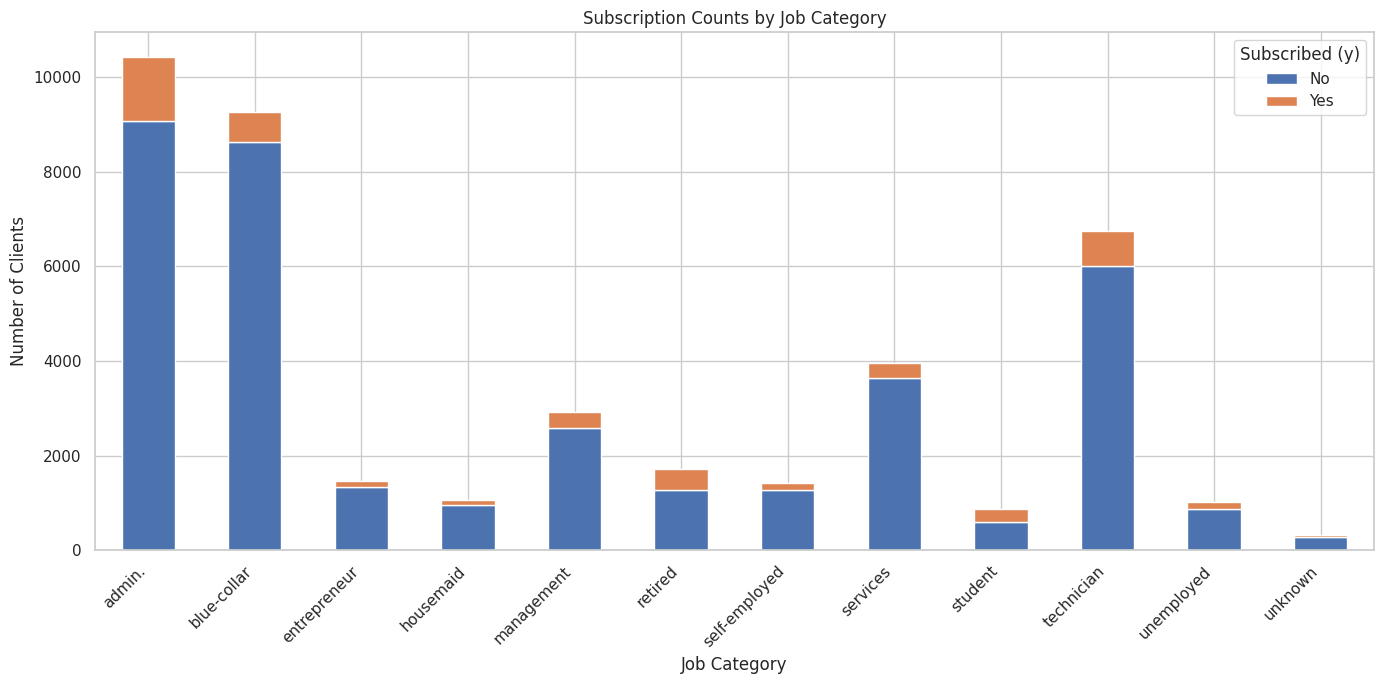

In [41]:
job_y_crosstab = pd.crosstab(df['job'], df['y'])

# Plotting the stacked bar chart
job_y_crosstab.plot(kind='bar', stacked=True, figsize=(14, 7))
plt.title('Subscription Counts by Job Category')
plt.xlabel('Job Category')
plt.ylabel('Number of Clients')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Subscribed (y)', labels=['No', 'Yes'])
plt.tight_layout()
plt.show()

Percentage of 'yes' subscriptions for each job category

In [42]:
# Calculate the total number of clients for each job category
job_y_crosstab['total'] = job_y_crosstab['no'] + job_y_crosstab['yes']

# Calculate the percentage of 'yes' subscriptions for each job category
job_y_crosstab['yes_percentage'] = (job_y_crosstab['yes'] / job_y_crosstab['total']) * 100

# Display the results, sorted by percentage
display(job_y_crosstab[['total', 'yes', 'yes_percentage']].sort_values(by='yes_percentage', ascending=False))

y,total,yes,yes_percentage
job,,,
student,875,275,31.428571
retired,1718,434,25.261932
unemployed,1014,144,14.201183
admin.,10419,1351,12.966695
management,2924,328,11.217510
unknown,330,37,11.212121
technician,6739,730,10.832468
self-employed,1421,149,10.485574
housemaid,1060,106,10.000000


### Detailed Breakdown of Subscriptions by Month

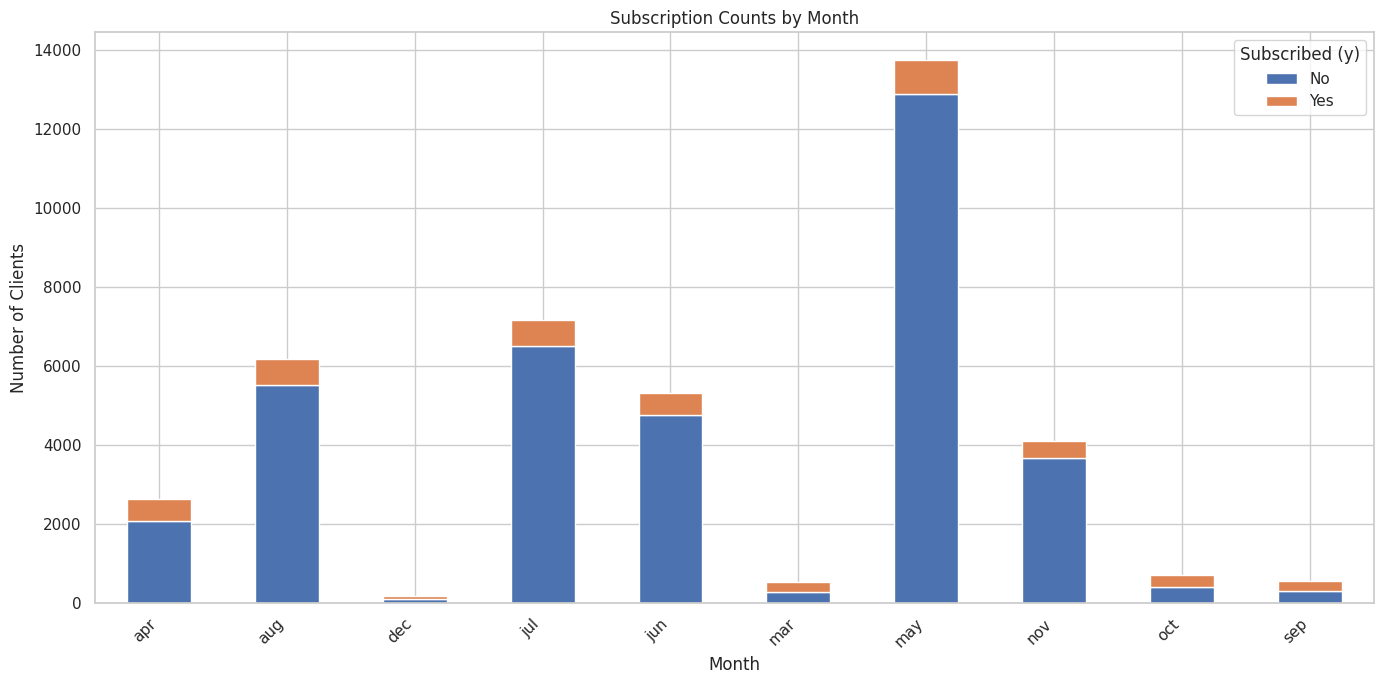

In [43]:
month_y_crosstab = pd.crosstab(df['month'], df['y'])

month_y_crosstab.plot(kind='bar', stacked=True, figsize=(14, 7))
plt.title('Subscription Counts by Month')
plt.xlabel('Month')
plt.ylabel('Number of Clients')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Subscribed (y)', labels=['No', 'Yes'])
plt.tight_layout()
plt.show()

### Percentage of 'yes' subscriptions for each month

In [44]:
# Calculate the total number of clients for each month
month_y_crosstab['total'] = month_y_crosstab['no'] + month_y_crosstab['yes']

# Calculate the percentage of 'yes' subscriptions for each month
month_y_crosstab['yes_percentage'] = (month_y_crosstab['yes'] / month_y_crosstab['total']) * 100

# Display the results, sorted by percentage
display(month_y_crosstab[['total', 'yes', 'yes_percentage']].sort_values(by='yes_percentage', ascending=False))

y,total,yes,yes_percentage
month,,,
mar,546,276,50.549451
dec,182,89,48.901099
sep,570,256,44.912281
oct,717,315,43.933054
apr,2631,539,20.486507
aug,6176,655,10.605570
jun,5318,559,10.511470
nov,4100,416,10.146341
jul,7169,648,9.038918


### Detailed Breakdown of Subscriptions by Education

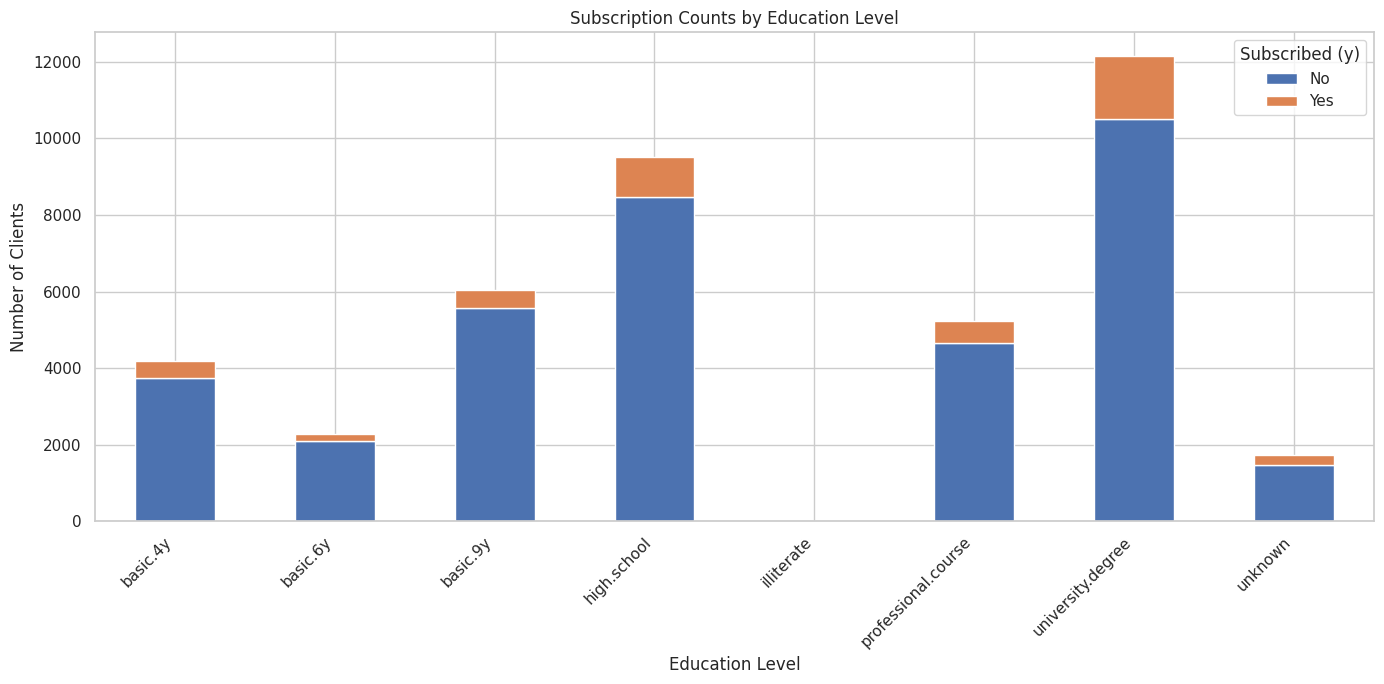

In [45]:
education_y_crosstab = pd.crosstab(df['education'], df['y'])

education_y_crosstab.plot(kind='bar', stacked=True, figsize=(14, 7))
plt.title('Subscription Counts by Education Level')
plt.xlabel('Education Level')
plt.ylabel('Number of Clients')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Subscribed (y)', labels=['No', 'Yes'])
plt.tight_layout()
plt.show()

### Percentage of 'yes' subscriptions for each education level

In [46]:
education_y_crosstab['total'] = education_y_crosstab['no'] + education_y_crosstab['yes']

# Calculate the percentage of 'yes' subscriptions for each education level
education_y_crosstab['yes_percentage'] = (education_y_crosstab['yes'] / education_y_crosstab['total']) * 100

# Display the results, sorted by percentage
display(education_y_crosstab[['total', 'yes', 'yes_percentage']].sort_values(by='yes_percentage', ascending=False))

y,total,yes,yes_percentage
education,,,
illiterate,18,4,22.222222
unknown,1730,251,14.508671
university.degree,12164,1669,13.720816
professional.course,5240,595,11.354962
high.school,9512,1031,10.838940
basic.4y,4176,428,10.249042
basic.6y,2291,188,8.206024
basic.9y,6045,473,7.824648


PREPROCESSING & FEATURE ENGINEERING

TARGET VARIABLE ENCODING

In [47]:
# Convert target variable ('yes'/'no') to numeric indices (1/0)
le = LabelEncoder()
df['y'] = le.fit_transform(df['y'])

SPLIT FEATURES AND TARGET


In [48]:
X = df.drop("y", axis=1)
y = df["y"]

In [49]:
# Splitting dataset before scaling/oversampling to isolate the test set completely
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)
print(f"Training set features shape: {X_train.shape}")
print(f"Testing set features shape:  {X_test.shape}")

Training set features shape: (32940, 20)
Testing set features shape:  (8236, 20)


In [50]:
# Separate numeric and categorical column lists
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X_train.select_dtypes(include=['object']).columns.tolist()

In [51]:
#Handle Numeric Columns (Scaling)
scaler = StandardScaler()
# Fit only on training data, transform both
X_train_num = scaler.fit_transform(X_train[num_cols])
X_test_num = scaler.transform(X_test[num_cols])

### One-Hot Encoding for Categorical Features

In [52]:
ohe = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')
# Fit only on training data, transform both
X_train_cat = ohe.fit_transform(X_train[cat_cols])
X_test_cat = ohe.transform(X_test[cat_cols])

In [53]:
#Combine scaled numeric features and encoded categorical features back together
X_train_processed = np.hstack((X_train_num, X_train_cat))
X_test_processed = np.hstack((X_test_num, X_test_cat))

print(f"Processed Train Shape: {X_train_processed.shape}")
print(f"Processed Test Shape:  {X_test_processed.shape}")


Processed Train Shape: (32940, 53)
Processed Test Shape:  (8236, 53)


In [54]:
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_processed, y_train)

print(f"After SMOTE target class count:  {np.bincount(y_train_resampled)}")

After SMOTE target class count:  [29229 29229]


### Hyperparameter Tuning

### Decision Tree

In [55]:
### Decision Tree

dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train_resampled, y_train_resampled)

DecisionTreeClassifier(max_depth=5, random_state=42)

### Decision Tree Evaluation

In [56]:
# Predictions
best_dt = dt
y_pred_dt = dt.predict(X_test_processed)
y_prob_dt = dt.predict_proba(X_test_processed)[:, 1]

# Metrics
accuracy_dt  = accuracy_score(y_test, y_pred_dt)
precision_dt = precision_score(y_test, y_pred_dt)
recall_dt    = recall_score(y_test, y_pred_dt)
f1_dt        = f1_score(y_test, y_pred_dt)
roc_auc_dt   = roc_auc_score(y_test, y_prob_dt)

print("Decision Tree Results")
print("Accuracy:",  accuracy_dt)
print("Precision:", precision_dt)
print("Recall:",    recall_dt)
print("F1-Score:",  f1_dt)
print("ROC AUC:",   roc_auc_dt)

Decision Tree Results
Accuracy: 0.8617047110247693
Precision: 0.4428803465078506
Recall: 0.8814655172413793
F1-Score: 0.5895495495495495
ROC AUC: 0.9271027971236057


### Random Forest

In [57]:
### Random Forest

rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_train_resampled, y_train_resampled)

RandomForestClassifier(max_depth=10, n_jobs=-1, random_state=42)

### Random Forest Evaluation

In [58]:
# Predictions
best_rf = rf
y_pred_rf = rf.predict(X_test_processed)
y_prob_rf = rf.predict_proba(X_test_processed)[:, 1]

# Metrics
accuracy_rf  = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf    = recall_score(y_test, y_pred_rf)
f1_rf        = f1_score(y_test, y_pred_rf)
roc_auc_rf   = roc_auc_score(y_test, y_prob_rf)

print("Random Forest Results")
print("Accuracy:",  accuracy_rf)
print("Precision:", precision_rf)
print("Recall:",    recall_rf)
print("F1-Score:",  f1_rf)
print("ROC AUC:",   roc_auc_rf)

Random Forest Results
Accuracy: 0.8818601262748907
Precision: 0.4866151100535396
Recall: 0.8814655172413793
F1-Score: 0.6270601763127636
ROC AUC: 0.9424163764792481


### XGBoost

In [59]:
### XGBoost

xgb = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    objective="binary:logistic",
    eval_metric="logloss",
    use_label_encoder=False,
    n_jobs=-1
)
xgb.fit(X_train_resampled, y_train_resampled)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=-1,
              num_parallel_tree=None, ...)

### XGBoost Evaluation

In [60]:
# Predictions
best_xgb = xgb
y_pred_xgb = xgb.predict(X_test_processed)
y_prob_xgb = xgb.predict_proba(X_test_processed)[:, 1]

# Metrics
accuracy_xgb  = accuracy_score(y_test, y_pred_xgb)
precision_xgb = precision_score(y_test, y_pred_xgb)
recall_xgb    = recall_score(y_test, y_pred_xgb)
f1_xgb        = f1_score(y_test, y_pred_xgb)
roc_auc_xgb   = roc_auc_score(y_test, y_prob_xgb)

print("XGBoost Results")
print("Accuracy:",  accuracy_xgb)
print("Precision:", precision_xgb)
print("Recall:",    recall_xgb)
print("F1-Score:",  f1_xgb)
print("ROC AUC:",   roc_auc_xgb)

XGBoost Results
Accuracy: 0.9095434677027683
Precision: 0.5768261964735516
Recall: 0.740301724137931
F1-Score: 0.6484190655969797
ROC AUC: 0.9477120756893721


### Compare All Models

In [61]:
results = pd.DataFrame({
    'Model': ['Decision Tree', 'Random Forest', 'XGBoost'],
    'Accuracy': [accuracy_dt, accuracy_rf, accuracy_xgb],
    'Precision': [precision_dt, precision_rf, precision_xgb],
    'Recall': [recall_dt, recall_rf, recall_xgb],
    'F1-Score': [f1_dt, f1_rf, f1_xgb],
    'ROC AUC': [roc_auc_dt, roc_auc_rf, roc_auc_xgb]
})

print(results.sort_values(by='ROC AUC', ascending=False))

# Select best model based on ROC AUC
best_idx = results['ROC AUC'].idxmax()
best_model_name = results.loc[best_idx, 'Model']
best_model = [best_dt, best_rf, best_xgb][best_idx]
print(f"\nBest model: {best_model_name}")

           Model  Accuracy  Precision    Recall  F1-Score   ROC AUC
2        XGBoost  0.909543   0.576826  0.740302  0.648419  0.947712
1  Random Forest  0.881860   0.486615  0.881466  0.627060  0.942416
0  Decision Tree  0.861705   0.442880  0.881466  0.589550  0.927103

Best model: XGBoost


### Confusion Matrix for Best Model

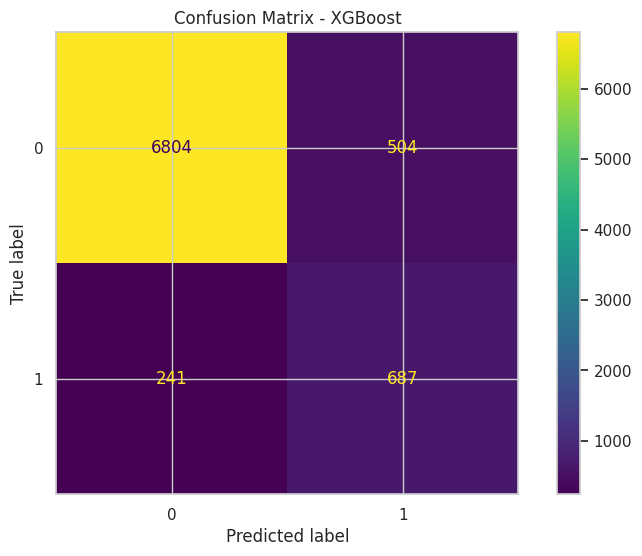

In [62]:
y_pred = best_model.predict(X_test_processed)

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title(f'Confusion Matrix - {best_model_name}')
plt.show()

### Classification Report

In [63]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.93      0.95      7308
           1       0.58      0.74      0.65       928

    accuracy                           0.91      8236
   macro avg       0.77      0.84      0.80      8236
weighted avg       0.92      0.91      0.91      8236



### ROC Curve and AUC

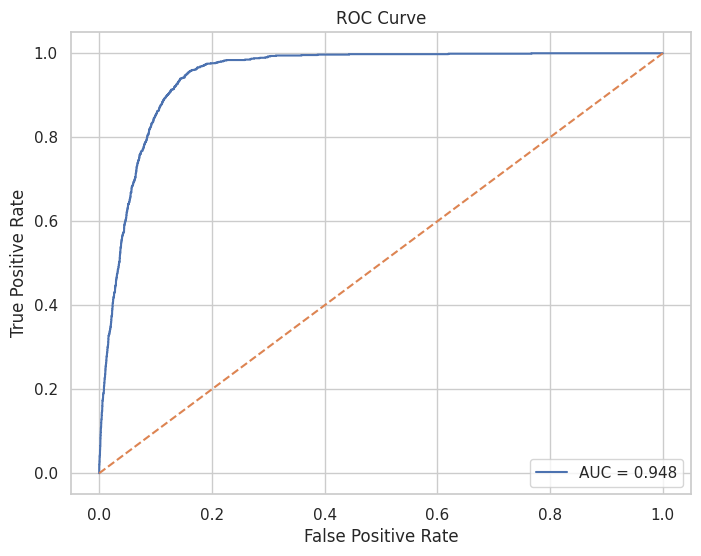

AUC Score: 0.9477120756893721


In [64]:
# Predicted probabilities
y_prob = best_model.predict_proba(X_test_processed)[:, 1]

# ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

print("AUC Score:", roc_auc)

In [65]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9095434677027683


### Feature Importance

In [66]:
# Build full feature name list after OHE
ohe_feature_names = ohe.get_feature_names_out(cat_cols).tolist()
all_feature_names = num_cols + ohe_feature_names

feature_importance = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': best_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance)

                          Feature  Importance
9                     nr.employed    0.155253
1                        duration    0.092417
7                   cons.conf.idx    0.054891
34                    housing_yes    0.047323
43                      month_may    0.044459
5                    emp.var.rate    0.037934
2                        campaign    0.035647
31                default_unknown    0.034259
45                      month_oct    0.033410
50                day_of_week_wed    0.025464
29    education_university.degree    0.024202
36                       loan_yes    0.024065
8                       euribor3m    0.023895
16                   job_services    0.023528
37              contact_telephone    0.023486
49                day_of_week_tue    0.022635
48                day_of_week_thu    0.019469
25             education_basic.9y    0.019448
47                day_of_week_mon    0.018867
10                job_blue-collar    0.017570
26          education_high.school 

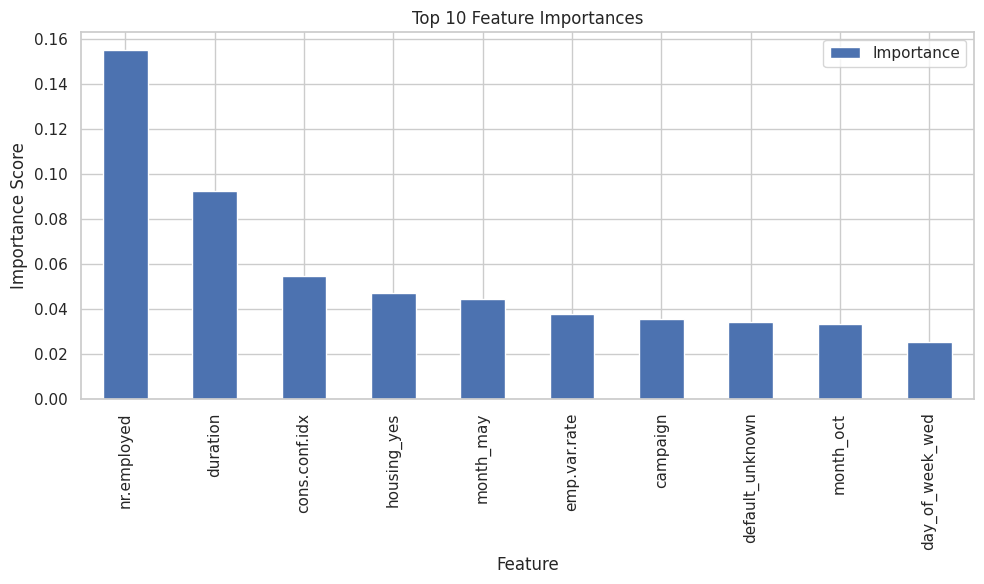

In [67]:
feature_importance.head(10).plot(
    x='Feature',
    y='Importance',
    kind='bar',
    figsize=(10, 6)
)

plt.title('Top 10 Feature Importances')
plt.ylabel('Importance Score')
plt.tight_layout()
plt.show()

In [68]:
print(feature_importance.head(10))

            Feature  Importance
9       nr.employed    0.155253
1          duration    0.092417
7     cons.conf.idx    0.054891
34      housing_yes    0.047323
43        month_may    0.044459
5      emp.var.rate    0.037934
2          campaign    0.035647
31  default_unknown    0.034259
45        month_oct    0.033410
50  day_of_week_wed    0.025464
